# Brain Tumor MRI Classification with a Simple CNN
### A Didactic Deep Learning Example for University Students
---
**Dataset:** [Brain Tumor MRI Dataset - Masoud Nickparvar (Kaggle)](https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset)

| Class | Train | Test |
|---|---|---|
| Glioma | 1 321 | 300 |
| Meningioma | 1 339 | 306 |
| No Tumor | 1 595 | 405 |
| Pituitary | 1 457 | 300 |
| **Total** | **5 712** | **1 311** |

**Learning objectives:**
1. Custom MRI preprocessing -- crop black margins, resize, normalise
2. Carving a validation split from a training folder (no data leakage)
3. CNN architecture: Conv -> BN -> ReLU -> MaxPool stacks built from scratch
4. Weighted Random Sampling to handle class imbalance
5. Early stopping, cosine LR scheduling, model checkpointing
6. Evaluation: accuracy, F1, confusion matrix, ROC-AUC
7. Grad-CAM -- visualising what the network looks at


## Step 0 — Install Dependencies

In [28]:
import os, zipfile, shutil, subprocess
from pathlib import Path

# 1. Install libraries
subprocess.run(["pip", "install", "torch", "torchvision", "matplotlib",
                "scikit-learn", "seaborn", "pillow", "tqdm", "--quiet"],
               check=True)
print("Libraries installed.")

# 2. Extract zip if present
ZIP_NAME = "BrainTumorMRI.zip"
CLASSES  = ["glioma", "meningioma", "notumor", "pituitary"]

zip_path = None
for base in [Path("."), Path("..")]:
    c = base / ZIP_NAME
    if c.exists():
        zip_path = c.resolve()
        break

if zip_path:
    print(f"Extracting {zip_path} ...")
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(".")
    print("Extraction complete.")
else:
    print("No zip found -- assuming folders already extracted.")

# 3. Auto-detect Training/ and Testing/ wherever they landed.
# The zip may extract to different layouts:
#   Layout A: ./Training/  and  ./Testing/           (root level)
#   Layout B: ./BrainTumorMRI/Training/  and  ./BrainTumorMRI/Testing/
#   Layout C: ./BrainTumorMRI/Training/  and  ./Testing/
# rglob finds them regardless of nesting depth.

def find_class_dir(name):
    for p in sorted(Path(".").rglob(name)):
        if p.is_dir() and all((p / c).is_dir() for c in CLASSES):
            return p
    return None

TRAIN_DIR = find_class_dir("Training")
TEST_DIR  = find_class_dir("Testing")

if TRAIN_DIR is None or TEST_DIR is None:
    contents = sorted(str(p) for p in Path(".").iterdir())
    raise RuntimeError(
        "Could not locate Training/ and/or Testing/ with all 4 class subfolders.\n"
        "Current directory:\n  " + "\n  ".join(contents) + "\n"
        "Make sure BrainTumorMRI.zip is in the same folder as this notebook."
    )

print(f"Training dir : {TRAIN_DIR}")
print(f"Testing dir  : {TEST_DIR}")

# 4. Image counts
print("")
for label, folder in [("Training", TRAIN_DIR), ("Testing", TEST_DIR)]:
    print(f"  {label}/")
    for cls_dir in sorted(folder.iterdir()):
        n = len(list(cls_dir.glob("*.*")))
        print(f"    {cls_dir.name:<14}{n} images")


Libraries installed.
Extracting /content/BrainTumorMRI.zip ...
Extraction complete.
Training dir : Training
Testing dir  : Testing

  Training/
    glioma        1400 images
    meningioma    1400 images
    notumor       1400 images
    pituitary     1400 images
  Testing/
    glioma        400 images
    meningioma    400 images
    notumor       400 images
    pituitary     400 images


## Step 1 — Imports

We import:
- **PyTorch** — deep learning framework (tensor ops, autograd, layers)
- **torchvision** — image datasets, transforms, pretrained models
- **scikit-learn** — evaluation metrics (F1, confusion matrix, ROC-AUC)
- **matplotlib / seaborn** — visualisation

In [29]:
import os, sys, time, copy, random, warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
)
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import label_binarize
from tqdm.notebook import tqdm   # notebook-friendly progress bars

warnings.filterwarnings("ignore")
print("All imports successful")

All imports successful


## Step 2 — Reproducibility

> **Why?**  Deep learning involves randomness at every stage:
> weight initialisation, data shuffling, dropout masks.
> Fixing all seeds guarantees that re-running this notebook gives identical results —
> essential for debugging and comparing experiments.

In [30]:
SEED = 42

def set_seed(seed: int) -> None:
    """Pin every source of randomness in the pipeline."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True   # Slightly slower, fully reproducible
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
print(f"Seed set to {SEED}")

Seed set to 42


## Step 3 -- Configuration

All hyperparameters live in one dictionary.
Change only this cell to run different experiments.

| Hyperparameter | Value | Meaning |
|---|---|---|
| `image_size` | 128 | Input resolution; smaller trains faster on CPU |
| `batch_size` | 32 | Images processed per gradient-update step |
| `num_epochs` | 20 | Maximum full passes over the training set |
| `val_fraction` | 0.15 | 15% of Training/ held out as validation |
| `learning_rate` | 1e-3 | Initial step size for the Adam optimiser |
| `weight_decay` | 1e-4 | L2 regularisation -- penalises large weights |
| `dropout` | 0.5 | Fraction of neurons randomly silenced each step |
| `patience` | 5 | Early-stop after N epochs with no improvement |


In [31]:
CONFIG = {
    # Paths
    "train_dir"      : "Training",
    "test_dir"       : "Testing",
    "checkpoint"     : "best_model.pth",

    # Image -- 128x128 trains faster and is sufficient to illustrate CNN concepts
    "image_size"     : 128,

    # Training
    "batch_size"     : 32,
    "num_epochs"     : 20,
    "val_fraction"   : 0.15,

    # Optimisation
    "learning_rate"  : 1e-3,
    "weight_decay"   : 1e-4,
    "dropout"        : 0.5,

    # Early stopping
    "patience"       : 5,

    # Misc
    "num_classes"    : 4,
    "num_workers"    : min(4, os.cpu_count()),
}

CLASS_NAMES = ["glioma", "meningioma", "notumor", "pituitary"]

print("Configuration loaded:")
for k, v in CONFIG.items():
    print(f"   {k:<18} = {v}")


Configuration loaded:
   train_dir          = Training
   test_dir           = Testing
   checkpoint         = best_model.pth
   image_size         = 128
   batch_size         = 32
   num_epochs         = 20
   val_fraction       = 0.15
   learning_rate      = 0.001
   weight_decay       = 0.0001
   dropout            = 0.5
   patience           = 5
   num_classes        = 4
   num_workers        = 2


## Step 4 — Device Selection (CPU vs GPU)

GPUs accelerate matrix operations by running thousands of small computations
in parallel. PyTorch seamlessly moves tensors between CPU and GPU.

`torch.device("cuda")` selects the NVIDIA GPU if available; otherwise we fall back to CPU.

In [32]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"VRAM   : {gb:.1f} GB")
else:
    print("No GPU found — training will be slow on CPU.")

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


## Step 5 — Custom Preprocessing: `CropBlackMargins`

**Why is this needed?**

MRI scans are placed on a black (zero-intensity) background.
Large black borders waste network capacity — the model might learn to look at
the padding rather than the brain tissue.

**Algorithm:**
1. Convert image to grayscale
2. Threshold at intensity = 10 → binary mask (brain = 1, background = 0)
3. Find bounding box of the non-zero (brain) pixels
4. Crop the original colour image to that bounding box

In [33]:
class CropBlackMargins:
    """
    Custom torchvision-compatible transform.
    Removes near-black (< threshold intensity) borders from MRI images.
    """
    def __init__(self, threshold: int = 10):
        self.threshold = threshold

    def __call__(self, img: Image.Image) -> Image.Image:
        arr  = np.array(img.convert("L"))           # Grayscale [H, W]
        mask = arr > self.threshold                  # Brain pixels = True

        if not mask.any():
            return img  # Safety: fully dark image, return unchanged

        rows = np.any(mask, axis=1)
        cols = np.any(mask, axis=0)
        rmin, rmax = np.where(rows)[0][[0, -1]]
        cmin, cmax = np.where(cols)[0][[0, -1]]

        # PIL crop(left, upper, right, lower)
        return img.crop((cmin, rmin, cmax + 1, rmax + 1))

    def __repr__(self):
        return f"CropBlackMargins(threshold={self.threshold})"

print(" CropBlackMargins transform defined")

 CropBlackMargins transform defined


## Step 6 — Data Transforms (Augmentation & Normalisation)

**Augmentation is applied ONLY to the training set.**

| Transform | Reason |
|---|---|
| `RandomCrop` | Simulates slight position variation of the brain in the scanner |
| `RandomHorizontalFlip` | Mirror of a brain scan is still anatomically valid |
| `RandomRotation(15)` | Scanners can position patients at slight angles |
| `ColorJitter` | Simulates brightness/contrast variation across MRI machines |
| `RandomErasing` | Randomly masks a patch — teaches robustness to occlusion |

**Normalisation** subtracts the ImageNet channel means and divides by std.
Required because we start from ImageNet-pretrained weights.

In [34]:
# For a CNN trained from scratch we do NOT need ImageNet statistics.
# We use 0.5 / 0.5 normalisation which maps pixel values from [0, 1]
# into [-1, 1], centring them around zero.

IMG_MEAN = [0.5, 0.5, 0.5]
IMG_STD  = [0.5, 0.5, 0.5]

TRANSFORMS = {
    "train": transforms.Compose([
        CropBlackMargins(threshold=10),
        transforms.Resize((CONFIG["image_size"] + 16, CONFIG["image_size"] + 16)),
        transforms.RandomCrop(CONFIG["image_size"]),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),                   # PIL [0,255] -> Tensor [0.0, 1.0]
        transforms.Normalize(IMG_MEAN, IMG_STD), # -> [-1.0, 1.0]
    ]),
    "val": transforms.Compose([
        CropBlackMargins(threshold=10),
        transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
        transforms.ToTensor(),
        transforms.Normalize(IMG_MEAN, IMG_STD),
    ]),
    "test": transforms.Compose([
        CropBlackMargins(threshold=10),
        transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
        transforms.ToTensor(),
        transforms.Normalize(IMG_MEAN, IMG_STD),
    ]),
}

print("Transforms defined.")
print("Train pipeline:")
for t in TRANSFORMS["train"].transforms:
    print("   ", t)


Transforms defined.
Train pipeline:
    CropBlackMargins(threshold=10)
    Resize(size=(144, 144), interpolation=bilinear, max_size=None, antialias=True)
    RandomCrop(size=(128, 128), padding=None)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=None, hue=None)
    ToTensor()
    Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])


## Step 7 — Dataset Loading & Validation Split

The Kaggle dataset provides `Training/` and `Testing/` but **no validation folder**.

**Strategy:**
- Load all of `Training/` with `ImageFolder`
- Use **`StratifiedShuffleSplit`** to split 85% / 15%
  - *Stratified* = every class keeps its proportion in both halves
  - This prevents a val set with very few meningioma images

**Data-leakage prevention:**  
`TransformSubset` wraps each split separately so training augmentation
is **never applied to validation images**.

In [35]:
class TransformSubset(torch.utils.data.Dataset):
    """
    Wraps a Subset and applies a specific transform.
    Prevents augmentation leaking into the validation split.
    """
    def __init__(self, subset, transform):
        self.subset    = subset
        self.transform = transform
        self.classes   = subset.dataset.classes
        self.targets   = [subset.dataset.targets[i] for i in subset.indices]

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img, label = self.subset[idx]   # img is PIL here (no transform on parent)
        if self.transform:
            img = self.transform(img)
        return img, label


def load_data(config):
    train_path = Path(config["train_dir"])
    test_path  = Path(config["test_dir"])

    if not train_path.exists():
        print(f"[ERROR] Training folder not found: {train_path}")
        print("   Running DEMO mode with random tensors...")
        return _demo_loaders(config)

    # Load full Training/ folder — NO transform yet (will apply per subset)
    full_train = datasets.ImageFolder(root=str(train_path), transform=None)
    # ImageFolder assigns alphabetical labels:
    # glioma=0, meningioma=1, notumor=2, pituitary=3
    print(f"   ImageFolder classes: {full_train.class_to_idx}")

    # Stratified 85/15 split
    sss = StratifiedShuffleSplit(n_splits=1, test_size=config["val_fraction"],
                                 random_state=SEED)
    train_idx, val_idx = next(sss.split(np.zeros(len(full_train.targets)),
                                        full_train.targets))

    train_ds = TransformSubset(Subset(full_train, train_idx), TRANSFORMS["train"])
    val_ds   = TransformSubset(Subset(full_train, val_idx),   TRANSFORMS["val"])
    test_ds  = datasets.ImageFolder(root=str(test_path), transform=TRANSFORMS["test"])

    datasets_dict = {"train": train_ds, "val": val_ds, "test": test_ds}

    # Weighted Random Sampler — corrects for minor class imbalance
    train_labels  = train_ds.targets
    class_counts  = np.bincount(train_labels)
    sample_w      = [1.0 / class_counts[t] for t in train_labels]
    sampler = WeightedRandomSampler(torch.DoubleTensor(sample_w),
                                    len(sample_w), replacement=True)

    loaders = {
        "train": DataLoader(train_ds, batch_size=config["batch_size"],
                            sampler=sampler, num_workers=config["num_workers"],
                            pin_memory=(DEVICE.type=="cuda")),
        "val"  : DataLoader(val_ds,   batch_size=config["batch_size"],
                            shuffle=False, num_workers=config["num_workers"],
                            pin_memory=(DEVICE.type=="cuda")),
        "test" : DataLoader(test_ds,  batch_size=config["batch_size"],
                            shuffle=False, num_workers=config["num_workers"],
                            pin_memory=(DEVICE.type=="cuda")),
    }
    sizes = {s: len(d) for s, d in datasets_dict.items()}
    return datasets_dict, loaders, sizes


def _demo_loaders(config):
    from torch.utils.data import TensorDataset
    n = 128
    X = torch.randn(n, 3, config["image_size"], config["image_size"])
    Y = torch.randint(0, config["num_classes"], (n,))
    ds = TensorDataset(X, Y)
    ld = DataLoader(ds, batch_size=config["batch_size"], shuffle=True)
    class FDS:
        targets = Y.tolist()
        def __len__(self): return n
        def __getitem__(self, i): return X[i], Y[i]
    fake = FDS()
    return ({"train":fake,"val":fake,"test":fake},
            {"train":ld,"val":ld,"test":ld},
            {"train":n,"val":n,"test":n})


print(" Data loading functions defined")

 Data loading functions defined


In [36]:
datasets_dict, loaders, sizes = load_data(CONFIG)

print(f"\n{'Split':<8} {'N':>5}  Class distribution")
print("─" * 55)
for split, ds in datasets_dict.items():
    counts = np.bincount(ds.targets, minlength=CONFIG["num_classes"])
    bar = "  ".join(f"{CLASS_NAMES[i]}:{counts[i]}" for i in range(len(counts)))
    print(f"{split:<8} {len(ds):>5}  {bar}")

   ImageFolder classes: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

Split        N  Class distribution
───────────────────────────────────────────────────────
train     4760  glioma:1190  meningioma:1190  notumor:1190  pituitary:1190
val        840  glioma:210  meningioma:210  notumor:210  pituitary:210
test      1600  glioma:400  meningioma:400  notumor:400  pituitary:400


## Step 8 — Visualise Sample Images

Let's inspect some raw training images and see the effect of `CropBlackMargins`.

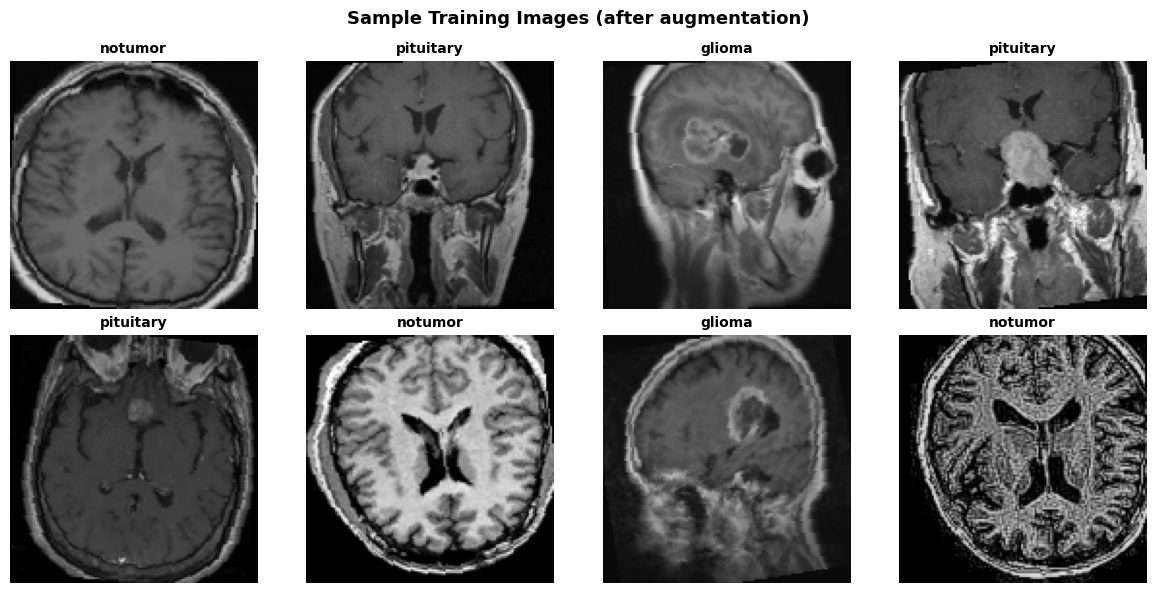

In [37]:
def show_samples(loader, n_cols=4, n_rows=2):
    """Display a grid of sample images from the loader."""
    mean = torch.tensor(IMG_MEAN).view(3,1,1)
    std  = torch.tensor(IMG_STD).view(3,1,1)

    imgs, labels = next(iter(loader))
    n = n_cols * n_rows

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
    fig.suptitle("Sample Training Images (after augmentation)", fontsize=13,
                 fontweight="bold")
    for i, ax in enumerate(axes.flat):
        if i >= n: break
        img = (imgs[i] * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
        ax.imshow(img)
        ax.set_title(CLASS_NAMES[labels[i].item()], fontsize=10, fontweight="bold")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

show_samples(loaders["train"])

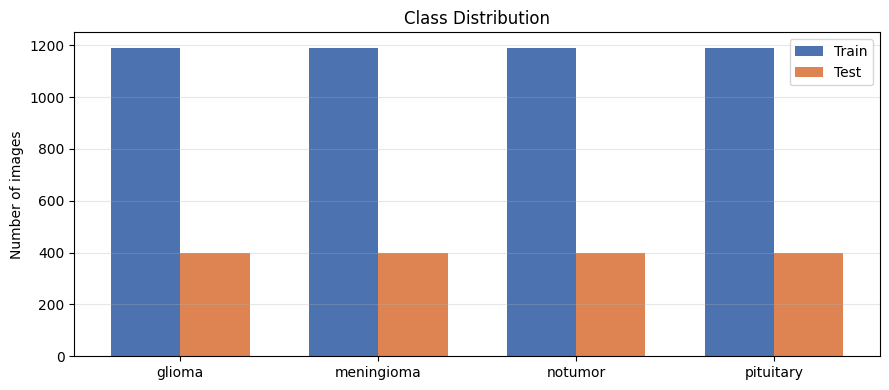

In [38]:
# Class distribution bar chart
counts_train = np.bincount(datasets_dict["train"].targets)
counts_test  = np.bincount(datasets_dict["test"].targets)

x = np.arange(len(CLASS_NAMES))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - width/2, counts_train, width, label="Train", color="#4C72B0")
ax.bar(x + width/2, counts_test,  width, label="Test",  color="#DD8452")
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES)
ax.set_ylabel("Number of images"); ax.set_title("Class Distribution")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

## Step 9 -- CNN Architecture

### ConvBlock: the fundamental building block

Each ConvBlock stacks three operations:

```
Conv2d  ->  BatchNorm2d  ->  ReLU  ->  MaxPool2d
```

| Layer | Role |
|---|---|
| Conv2d | Slides a 3x3 filter over the image and learns to detect local patterns: edges, curves, textures |
| BatchNorm2d | Normalises activations within the batch -- stabilises and speeds up training |
| ReLU | f(x) = max(0, x). Introduces non-linearity so the network can learn complex functions |
| MaxPool2d | Downsamples by 2x -- keeps the strongest activation in each 2x2 window |

### Tensor shape trace through BrainTumorCNN (input 128x128)

```
Input        : [B,   3, 128, 128]
After Block1 : [B,  32,  64,  64]   Conv(3->32)   + MaxPool
After Block2 : [B,  64,  32,  32]   Conv(32->64)  + MaxPool
After Block3 : [B, 128,  16,  16]   Conv(64->128) + MaxPool
After Block4 : [B, 256,   8,   8]   Conv(128->256)+ MaxPool
After GAP    : [B, 256,   1,   1]   Global Average Pool
After Flatten: [B, 256]
FC1          : [B, 128]
FC2 (output) : [B,   4]             one logit per class
```


In [39]:
class ConvBlock(nn.Module):
    """
    One stage of the CNN:
        Conv2d(3x3) -> BatchNorm2d -> ReLU -> MaxPool2d(2x2)

    After each block the spatial size halves (MaxPool stride=2) and the
    number of channels doubles -- a standard CNN design pattern.
    """
    def __init__(self, in_channels, out_channels, pool=True):
        super().__init__()
        layers = [
            # bias=False because BatchNorm already adds a learnable shift (beta)
            nn.Conv2d(in_channels, out_channels,
                      kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        ]
        if pool:
            layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class BrainTumorCNN(nn.Module):
    """
    A simple 4-block CNN for brain tumour classification.
    Built entirely from scratch -- no pretrained weights.
    """
    def __init__(self, num_classes=4, dropout=0.5):
        super().__init__()

        # Feature extractor: learns increasingly abstract spatial features
        self.features = nn.Sequential(
            ConvBlock(  3,  32),   # (B,  3, 128, 128) -> (B,  32, 64, 64)
            ConvBlock( 32,  64),   # (B, 32,  64,  64) -> (B,  64, 32, 32)
            ConvBlock( 64, 128),   # (B, 64,  32,  32) -> (B, 128, 16, 16)
            ConvBlock(128, 256),   # (B,128,  16,  16) -> (B, 256,  8,  8)
        )

        # Global Average Pooling: (B, 256, 8, 8) -> (B, 256, 1, 1)
        # Replaces flattening -- far fewer parameters, better generalisation
        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        # Classifier head
        self.classifier = nn.Sequential(
            nn.Flatten(),                 # (B, 256, 1, 1) -> (B, 256)
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(128, num_classes),  # (B, 128) -> (B, 4)  raw logits
        )

        self._init_weights()

    def _init_weights(self):
        """
        Kaiming (He) initialisation keeps gradient variance stable at the
        start of training, preventing vanishing/exploding gradients.
        """
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
            elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.features(x)    # spatial feature extraction
        x = self.gap(x)         # global pooling
        x = self.classifier(x)  # classification
        return x


# Sanity check: verify output shape before training
_x   = torch.randn(4, 3, CONFIG["image_size"], CONFIG["image_size"])
_m   = BrainTumorCNN(num_classes=CONFIG["num_classes"])
_out = _m(_x)
print(f"Input shape  : {list(_x.shape)}")
print(f"Output shape : {list(_out.shape)}  (expect [4, 4])")
print(f"Total parameters: {sum(p.numel() for p in _m.parameters()):,}")
del _x, _m, _out


Input shape  : [4, 3, 128, 128]
Output shape : [4, 4]  (expect [4, 4])
Total parameters: 422,564


## Step 10 -- Loss Function: Cross-Entropy

**Cross-Entropy Loss** is the standard loss for multi-class classification.

For a sample with true class c and raw logits z_0 ... z_3:

    softmax(z)_c = exp(z_c) / sum_k( exp(z_k) )
    Loss = -log( softmax(z)_c )

The loss is large when the model assigns low probability to the correct class,
and approaches zero as the predicted probability approaches 1.

nn.CrossEntropyLoss combines LogSoftmax and NLLLoss in one step,
so we feed it raw logits -- NOT softmax outputs.


In [40]:
# Plain cross-entropy loss -- no label smoothing needed for this educational example
criterion = nn.CrossEntropyLoss()
print("Loss function: nn.CrossEntropyLoss()")


Loss function: nn.CrossEntropyLoss()


## Step 12 — Training & Evaluation Loops

### The 6-step training loop (per mini-batch)

```
(1) zero_grad()    — clear accumulated gradients from previous step
(2) forward()      — compute predictions (logits)
(3) loss()         — cross-entropy between logits and true labels
(4) backward()     — backpropagate: compute L/W for every parameter W
 clip_grad_norm — cap gradient L2-norm to 1.0 (prevents exploding gradients)
 step()         — update W ← W  lr × L/W  (AdamW variant)
```

**`model.train()` vs `model.eval()`**
- `train()`: Dropout active, BatchNorm uses batch statistics
- `eval()` : Dropout disabled, BatchNorm uses running statistics

In [41]:
def train_one_epoch(model, loader, optimizer, device, epoch):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    bar = tqdm(loader, desc=f"Epoch {epoch:3d} [train]", leave=False)
    for imgs, labels in bar:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()                                    # (1) clear grads
        logits = model(imgs)                                     # (2) forward
        loss   = criterion(logits, labels)                       # (3) loss
        loss.backward()                                          # (4) backprop
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  #  clip
        optimizer.step()                                         #  update

        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
        bar.set_postfix(loss=f"{loss.item():.3f}")

    return total_loss / total, correct / total


@torch.no_grad()
def validate(model, loader, device, phase="val"):
    """No gradient computation needed — saves memory and time."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    for imgs, labels in tqdm(loader, desc=f"       [{phase:5s}]", leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        logits = model(imgs)
        loss   = criterion(logits, labels)

        total_loss += loss.item() * imgs.size(0)
        preds       = logits.argmax(1)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return total_loss / total, correct / total, all_preds, all_labels

print("Training and validation loops defined")

Training and validation loops defined


## Step 12 -- Full Training Pipeline

The training loop ties everything together:

- **Adam optimiser** -- adapts the learning rate per parameter using gradient history
- **Cosine Annealing LR** -- decays the learning rate smoothly from start to end
- **Early Stopping** -- halts training when validation accuracy stops improving
- **Model Checkpointing** -- saves the best weights seen during training


In [42]:
def train_model(model, loaders, config, device):
    """
    Full training loop with cosine LR decay, early stopping,
    and best-model checkpointing.
    """
    model = model.to(device)

    optimizer = optim.Adam(
        model.parameters(),
        lr           = config["learning_rate"],
        weight_decay = config["weight_decay"],
    )

    # Cosine Annealing: lr starts at learning_rate and decays smoothly to
    # learning_rate * 0.01 by the final epoch.
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max   = config["num_epochs"],
        eta_min = config["learning_rate"] * 0.01,
    )

    history = {k: [] for k in ("train_loss", "val_loss", "train_acc", "val_acc", "lr")}
    best_acc     = 0.0
    patience_ctr = 0
    best_weights = copy.deepcopy(model.state_dict())

    print(f"{'Ep':>3}  {'TrLoss':>8}  {'TrAcc':>7}  {'VaLoss':>8}  {'VaAcc':>7}  {'LR':>9}")
    print("-" * 55)

    for epoch in range(1, config["num_epochs"] + 1):
        t0 = time.time()

        tr_loss, tr_acc       = train_one_epoch(model, loaders["train"],
                                                optimizer, device, epoch)
        va_loss, va_acc, _, _ = validate(model, loaders["val"], device)

        scheduler.step()
        lr_now = scheduler.get_last_lr()[0]

        for k, v in zip(
            ("train_loss", "val_loss", "train_acc", "val_acc", "lr"),
            (tr_loss, va_loss, tr_acc, va_acc, lr_now),
        ):
            history[k].append(v)

        marker = " <-- best" if va_acc > best_acc else ""
        print(f"{epoch:>3}  {tr_loss:>8.4f}  {tr_acc:>7.4f}"
              f"  {va_loss:>8.4f}  {va_acc:>7.4f}  {lr_now:>9.2e}"
              f"  [{time.time()-t0:.0f}s]{marker}")

        if va_acc > best_acc:
            best_acc     = va_acc
            best_weights = copy.deepcopy(model.state_dict())
            torch.save(best_weights, config["checkpoint"])
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= config["patience"]:
                print(f"Early stop: no improvement for {config['patience']} epochs.")
                break

    model.load_state_dict(best_weights)
    print(f"\nBest val accuracy: {best_acc:.4f}  -- saved to {config['checkpoint']}")
    return model, history

print("Training pipeline defined.")


Training pipeline defined.


In [43]:
model = BrainTumorCNN(
    num_classes = CONFIG["num_classes"],
    dropout     = CONFIG["dropout"],
)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model      : BrainTumorCNN (trained from scratch)")
print(f"Parameters : {total_params:,}")
print()

model, history = train_model(model, loaders, CONFIG, DEVICE)


Model      : BrainTumorCNN (trained from scratch)
Parameters : 422,564

 Ep    TrLoss    TrAcc    VaLoss    VaAcc         LR
-------------------------------------------------------


Epoch   1 [train]:   0%|          | 0/149 [00:00<?, ?it/s]

       [val  ]:   0%|          | 0/27 [00:00<?, ?it/s]

  1    0.9671   0.5973    3.3512   0.2726   9.94e-04  [36s] <-- best


Epoch   2 [train]:   0%|          | 0/149 [00:00<?, ?it/s]

...

       [val  ]:   0%|          | 0/27 [00:00<?, ?it/s]

 19    0.2266   0.9158    0.2567   0.9012   1.61e-05  [24s]


Epoch  20 [train]:   0%|          | 0/149 [00:00<?, ?it/s]

       [val  ]:   0%|          | 0/27 [00:00<?, ?it/s]

 20    0.2134   0.9223    0.2808   0.8905   1.00e-05  [24s]

Best val accuracy: 0.9155  -- saved to best_model.pth


## Step 14 — Training Curves

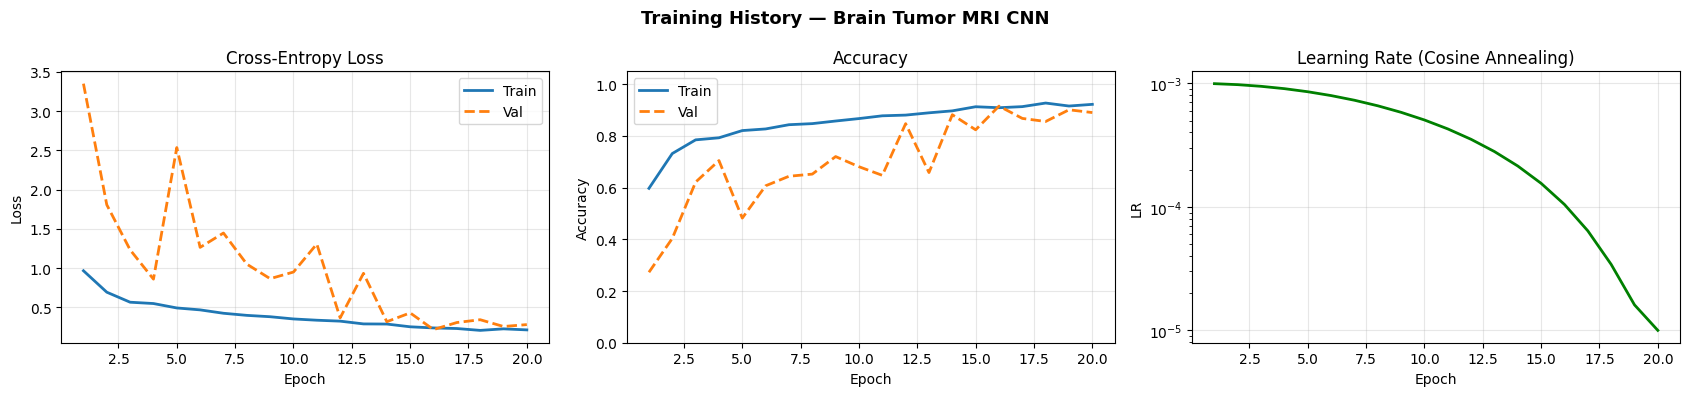

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
fig.suptitle("Training History — Brain Tumor MRI CNN", fontweight="bold", fontsize=13)
ep = range(1, len(history["train_loss"]) + 1)

axes[0].plot(ep, history["train_loss"], label="Train", lw=2)
axes[0].plot(ep, history["val_loss"],   label="Val",   lw=2, ls="--")
axes[0].set(title="Cross-Entropy Loss", xlabel="Epoch", ylabel="Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, history["train_acc"], label="Train", lw=2)
axes[1].plot(ep, history["val_acc"],   label="Val",   lw=2, ls="--")
axes[1].set(title="Accuracy", xlabel="Epoch", ylabel="Accuracy", ylim=[0, 1.05])
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(ep, history["lr"], color="green", lw=2)
axes[2].set(title="Learning Rate (Cosine Annealing)", xlabel="Epoch",
            ylabel="LR", yscale="log")
axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## Step 15 — Test Set Evaluation

We evaluate on the **held-out test set** — data the model has never seen.

**Metrics:**

| Metric | Formula | Clinical relevance |
|---|---|---|
| **Precision** | TP / (TP+FP) | Avoid false tumor detections |
| **Recall** | TP / (TP+FN) | **Don't miss real tumors!** |
| **F1-Score** | 2PR/(P+R) | Balance of both |
| **ROC-AUC** | Area under ROC curve | 1.0=perfect, 0.5=random |

In [45]:
@torch.no_grad()
def full_evaluate(model, loader, device):
    model.eval()
    preds, labels, probs = [], [], []

    for imgs, lbls in tqdm(loader, desc="Testing"):
        logits = model(imgs.to(device))
        p      = torch.softmax(logits, dim=1)
        preds.extend(logits.argmax(1).cpu().numpy())
        labels.extend(lbls.numpy())
        probs.extend(p.cpu().numpy())

    preds  = np.array(preds)
    labels = np.array(labels)
    probs  = np.array(probs)

    print("\n── Classification Report ──────────────────────────────────")
    print(classification_report(labels, preds, target_names=CLASS_NAMES, digits=4))

    try:
        lb  = label_binarize(labels, classes=range(CONFIG["num_classes"]))
        auc = roc_auc_score(lb, probs, multi_class="ovr", average="macro")
        print(f"Macro ROC-AUC: {auc:.4f}")
    except Exception as e:
        auc = None
        print(f"ROC-AUC skipped: {e}")

    return {"preds": preds, "labels": labels, "probs": probs, "auc": auc}


results = full_evaluate(model, loaders["test"], DEVICE)

Testing:   0%|          | 0/50 [00:00<?, ?it/s]


── Classification Report ──────────────────────────────────
              precision    recall  f1-score   support

      glioma     0.9167    0.7150    0.8034       400
  meningioma     0.7951    0.8150    0.8049       400
     notumor     0.8081    1.0000    0.8939       400
   pituitary     0.9530    0.9125    0.9323       400

    accuracy                         0.8606      1600
   macro avg     0.8682    0.8606    0.8586      1600
weighted avg     0.8682    0.8606    0.8586      1600

Macro ROC-AUC: 0.9655


## Step 16 — Confusion Matrix

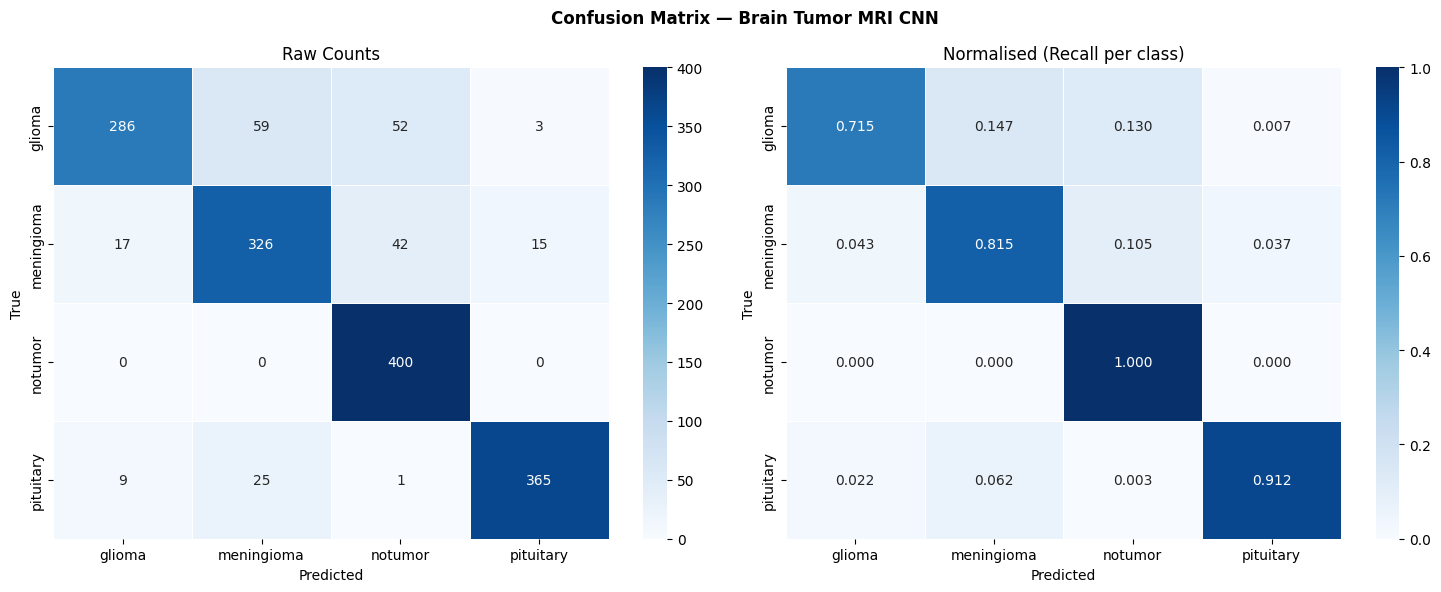

In [46]:
cm   = confusion_matrix(results["labels"], results["preds"])
cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Confusion Matrix — Brain Tumor MRI CNN", fontweight="bold")

for ax, data, title, fmt in zip(axes,
    [cm, cm_n],
    ["Raw Counts", "Normalised (Recall per class)"],
    ["d", ".3f"]):
    sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, linewidths=0.5)
    ax.set(title=title, xlabel="Predicted", ylabel="True")

plt.tight_layout(); plt.show()

## Step 17 — ROC Curves (One-vs-Rest)

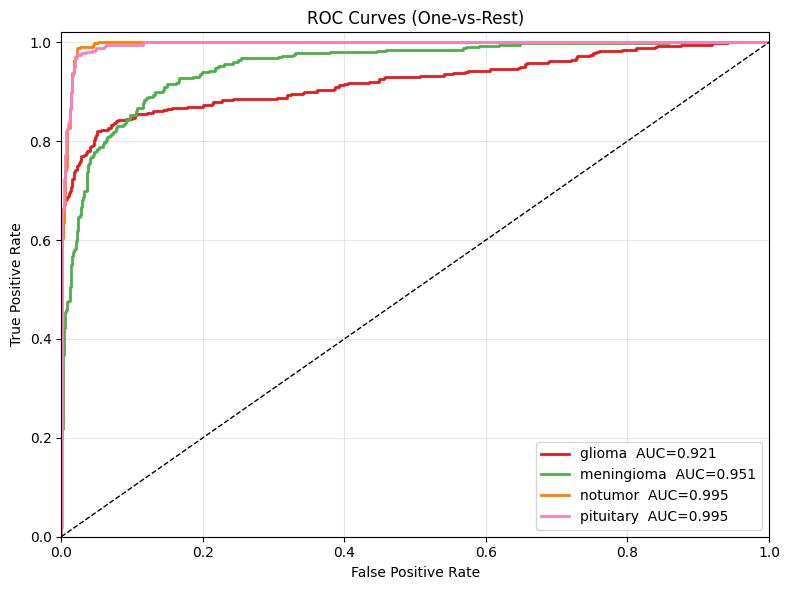

In [47]:
lb     = label_binarize(results["labels"], classes=range(CONFIG["num_classes"]))
colors = plt.cm.Set1(np.linspace(0, 0.8, CONFIG["num_classes"]))

fig, ax = plt.subplots(figsize=(8, 6))
for i, (cls, col) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(lb[:, i], results["probs"][:, i])
    auc_i = roc_auc_score(lb[:, i], results["probs"][:, i])
    ax.plot(fpr, tpr, color=col, lw=2, label=f"{cls}  AUC={auc_i:.3f}")

ax.plot([0,1],[0,1],"k--",lw=1)
ax.set(xlabel="False Positive Rate", ylabel="True Positive Rate",
       title="ROC Curves (One-vs-Rest)", xlim=[0,1], ylim=[0,1.02])
ax.legend(loc="lower right"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Step 18 — Sample Predictions

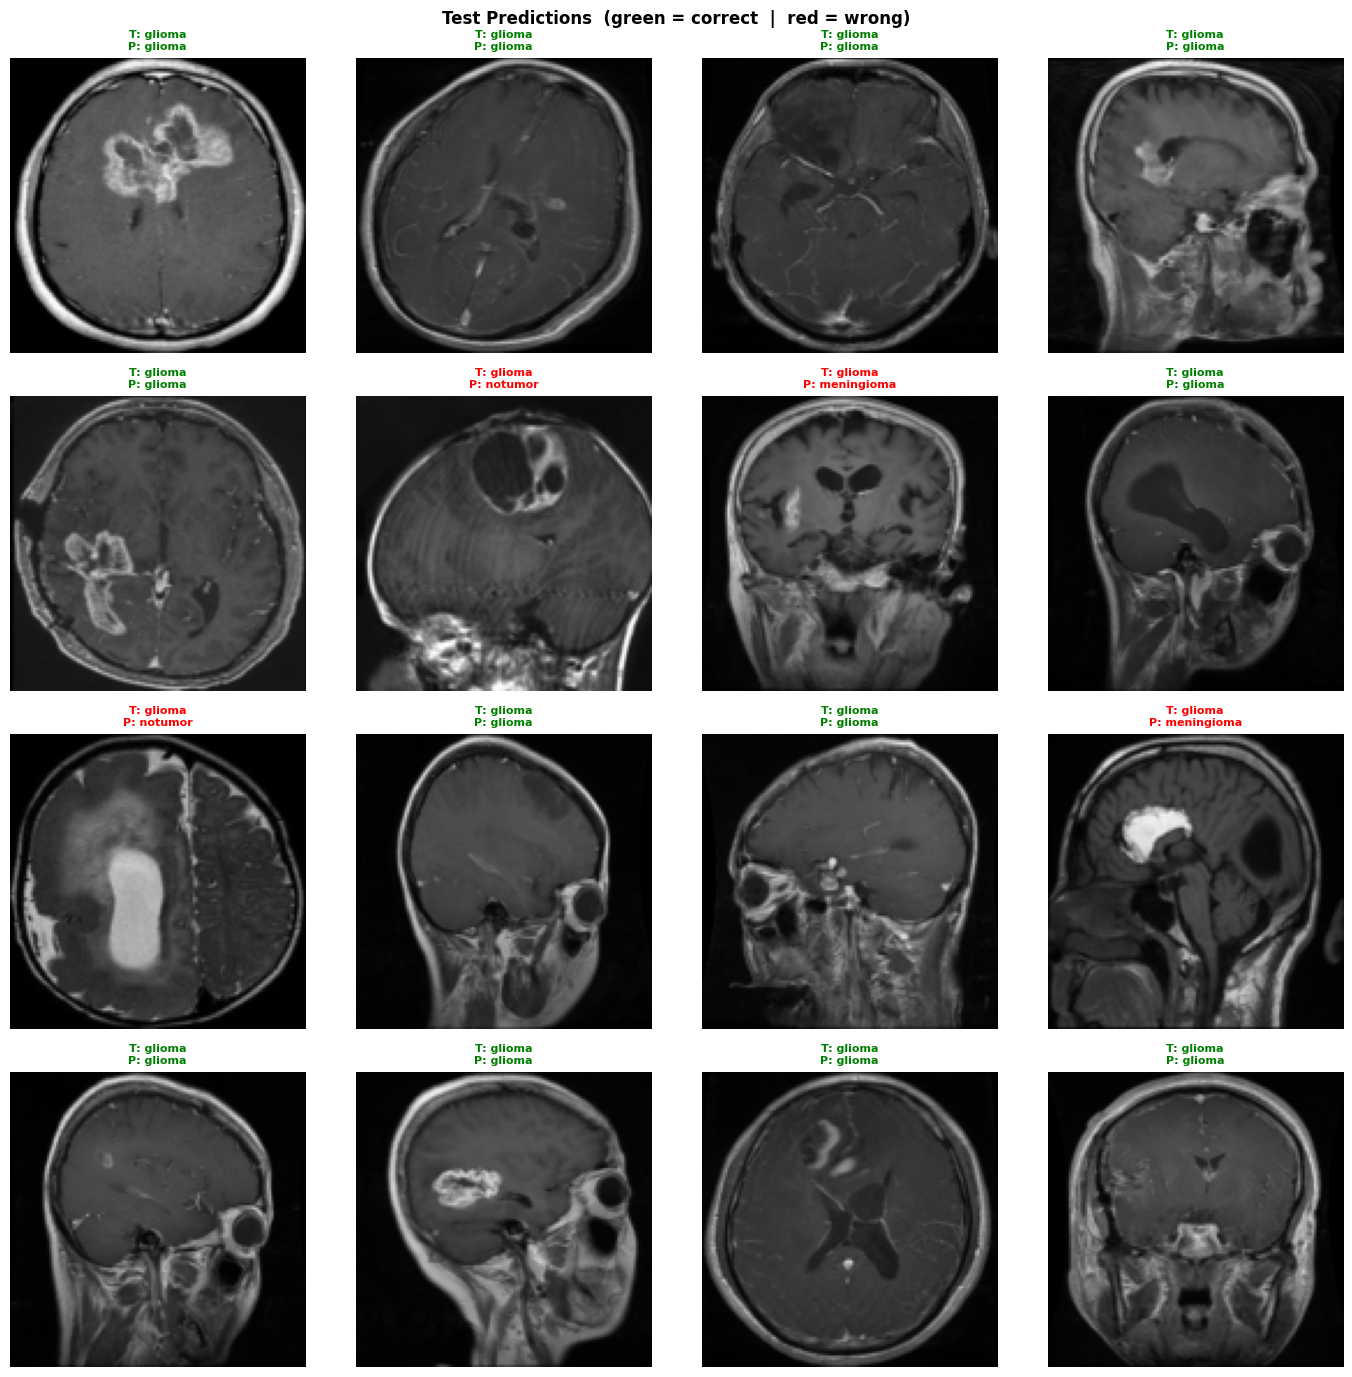

In [48]:
mean_t = torch.tensor(IMG_MEAN).view(3, 1, 1)
std_t  = torch.tensor(IMG_STD).view(3, 1, 1)

model.eval()
fig, axes = plt.subplots(4, 4, figsize=(14, 14))
fig.suptitle("Test Predictions  (green = correct  |  red = wrong)",
             fontsize=12, fontweight="bold")
shown = 0

with torch.no_grad():
    for imgs, lbls in loaders["test"]:
        preds = model(imgs.to(DEVICE)).argmax(1).cpu()
        for img, true, pred in zip(imgs, lbls, preds):
            if shown >= 16:
                break
            ax    = axes[shown // 4][shown % 4]
            npimg = (img * std_t + mean_t).clamp(0, 1).permute(1, 2, 0).numpy()
            ax.imshow(npimg)
            col = "green" if true == pred else "red"
            ax.set_title(
                f"T: {CLASS_NAMES[true]}\nP: {CLASS_NAMES[pred]}",
                fontsize=8, color=col, fontweight="bold"
            )
            ax.axis("off")
            shown += 1
        if shown >= 16:
            break

plt.tight_layout()
plt.show()


## Step 19 — Grad-CAM: Explainability

**Gradient-weighted Class Activation Mapping** highlights which image regions
drove the model's prediction.

### Algorithm

1. Forward pass → record feature maps $A^k$ at the last conv layer
2. Backpropagate only the predicted-class score (not the full loss)
3. Importance weight: $\alpha_k = \frac{1}{Z}\sum_{ij} \frac{\partial y^c}{\partial A^k_{ij}}$
4. Heatmap: $L^c = \text{ReLU}\!\left(\sum_k \alpha_k A^k\right)$
5. Upsample to input resolution and overlay

**Medical relevance:** Confirms the network focuses on the tumor mass,
not on scanner artefacts or image borders.

In [49]:
class GradCAM:
    """Gradient-weighted Class Activation Mapping for PyTorch models."""
    def __init__(self, model, target_layer):
        self.model = model
        self._acts = self._grads = None
        target_layer.register_forward_hook(
            lambda m,i,o: setattr(self, "_acts", o.detach()))
        target_layer.register_full_backward_hook(
            lambda m,gi,go: setattr(self, "_grads", go[0].detach()))

    def __call__(self, x, class_idx=None):
        self.model.eval()
        x      = x.unsqueeze(0).to(DEVICE)
        logits = self.model(x)
        idx    = class_idx if class_idx is not None else logits.argmax(1).item()

        self.model.zero_grad()
        logits[0, idx].backward()   # Gradient of class score only

        weights = self._grads.mean(dim=(2,3), keepdim=True)   # α_k
        cam     = (weights * self._acts).sum(dim=1).squeeze()
        cam     = torch.relu(cam)
        cam     = (cam - cam.min()) / (cam.max() + 1e-8)
        return cam.cpu().numpy()

print("GradCAM class defined")

GradCAM class defined


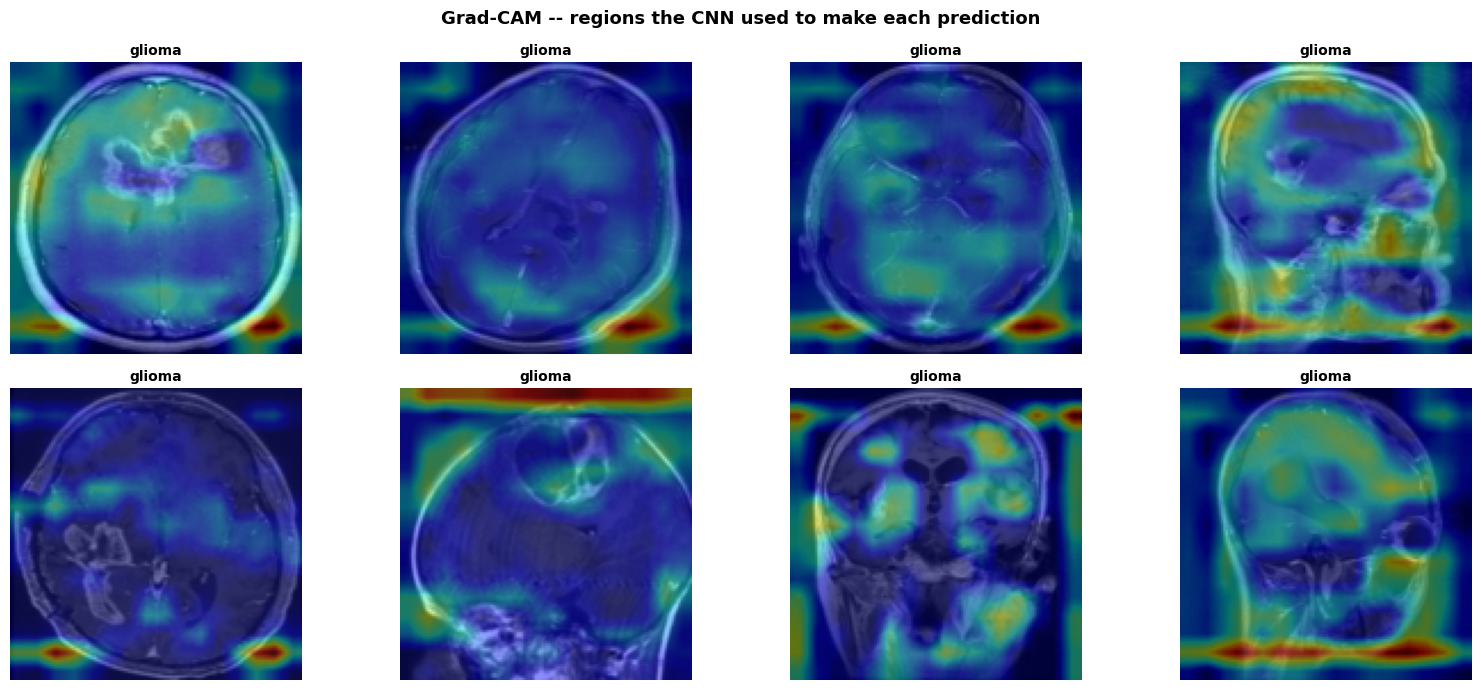

In [50]:
# Target the last Conv2d inside the last ConvBlock of the feature extractor.
# This is where the most abstract (semantically meaningful) feature maps live.
target_layer = model.features[-1].block[0]

cam_fn = GradCAM(model, target_layer)
mean_t = torch.tensor(IMG_MEAN).view(3, 1, 1)
std_t  = torch.tensor(IMG_STD).view(3, 1, 1)

n = 8
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle("Grad-CAM -- regions the CNN used to make each prediction",
             fontweight="bold", fontsize=13)
shown = 0

model.eval()
for imgs, lbls in loaders["test"]:
    for img, lbl in zip(imgs, lbls):
        if shown >= n:
            break
        cam   = cam_fn(img)
        npimg = (img * std_t + mean_t).clamp(0, 1).permute(1, 2, 0).numpy()
        cam_up = np.array(
            Image.fromarray((cam * 255).astype(np.uint8)).resize(
                (CONFIG["image_size"], CONFIG["image_size"]), Image.BILINEAR
            )
        ) / 255.0

        ax = axes.flat[shown]
        ax.imshow(npimg)
        ax.imshow(cam_up, cmap="jet", alpha=0.45)
        ax.set_title(CLASS_NAMES[lbl.item()], fontsize=10, fontweight="bold")
        ax.axis("off")
        shown += 1
    if shown >= n:
        break

plt.tight_layout()
plt.show()


## Step 18 -- Summary & Key Takeaways

| Step | Concept | Purpose |
|---|---|---|
| 1 | CropBlackMargins | Remove black MRI borders before resizing |
| 2 | StratifiedShuffleSplit | Create val split while keeping class ratios |
| 3 | WeightedRandomSampler | Counter class imbalance during training |
| 4 | Data Augmentation | Flip, rotate, jitter -- reduces overfitting |
| 5 | ConvBlock (Conv+BN+ReLU+MaxPool) | Core spatial feature detector |
| 6 | Stacked ConvBlocks | Hierarchical features: edges -> shapes -> tumour patterns |
| 7 | Global Average Pooling | Compact representation, fewer parameters than Flatten |
| 8 | Dropout | Prevents co-adaptation of neurons (regularisation) |
| 9 | Kaiming Initialisation | Keeps gradient variance stable at start of training |
| 10 | CrossEntropyLoss | Standard loss for multi-class classification |
| 11 | Backpropagation | Chain rule -- computes gradient of loss w.r.t. every weight |
| 12 | Adam + Cosine LR | Adaptive optimiser with smooth learning rate decay |
| 13 | Early Stopping | Automatically stops when model stops improving |
| 14 | Grad-CAM | Shows which image regions drove the prediction |
| 15 | Confusion Matrix + ROC-AUC + F1 | Evaluate beyond simple accuracy |
